# Projeto de Desempenho - TJDFT (Juizado Especial)

## Fase 1: Entendimento dos Dados (Data Understanding)

In [ ]:
import pandas as pd
import os
from google.colab import drive

# ======================================================================
# FASE 1: ENTENDIMENTO DO NEGÓCIO (BUSINESS UNDERSTANDING)
# ======================================================================
# Objetivo de Negócio:
# O objetivo é construir um painel de Business Intelligence (BI) para os gestores do
# Tribunal de Justiça do Distrito Federal e dos Territórios (TJDFT), com foco em
# Juizado Especial, analisando desempenho por período e por região administrativa.

# Perguntas de Negócio a serem respondidas pelo painel:
  # - Qual a produtividade do Juizado Especial? Estamos resolvendo mais casos do que entram?
# - Qual o tempo médio de tramitação dos processos no Juizado Especial?
# - Qual o volume de processos pendentes no Juizado Especial sem movimentação por mais de 120 dias?
# - Quais são os temas mais recorrentes e as principais partes (litigantes) nos processos do Juizado Especial?
# - Como se comportam os indicadores de desempenho (novos, baixados, pendentes) ano a ano?
# - Qual a distribuição dos processos de Juizado Especial por região administrativa (município) no DF?

# ======================================================================
# FASE 2: ENTENDIMENTO DOS DADOS (DATA UNDERSTANDING)
# ======================================================================
# As bases de dados são os arquivos .csv do CNJ, que já foram pré-filtrados para conter
# apenas dados do TJDFT. A análise a seguir visa entender a estrutura de cada arquivo
# para que possamos planejar a consolidação e a criação dos indicadores.


print("Iniciando a Fase 2 (Entendimento dos Dados) com análise de colunas.")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_brutos = "/content/drive/MyDrive/Projeto Final - CD/brutos"
    lista_arquivos_csv = [f for f in os.listdir(caminho_dados_brutos) if f.endswith('.csv')]
    print(f"Arquivos CSV encontrados: {lista_arquivos_csv}")
except Exception as e:
    print(f"Erro ao montar o Google Drive ou listar arquivos: {e}")
    exit()

for nome_arquivo in lista_arquivos_csv:
    caminho_completo = os.path.join(caminho_dados_brutos, nome_arquivo)

    try:
        df = pd.read_csv(caminho_completo, sep=';', encoding='utf-8-sig', low_memory=False)
        df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('.', '_', regex=False)

        print(f"\n==========================================================")
        print(f"ANALISANDO: {nome_arquivo}")
        print(f"==========================================================")

        print(f"Dimensões: {df.shape}")
        print("\nPrimeiras 5 linhas:")
        print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
        print("\nTipos de dados e contagem de valores:")
        df.info()

        # Análise lógica de cada coluna para o painel final
        print("\n--- LÓGICA DE CÁLCULO E RELEVÂNCIA ---")

        # Chave de união entre os arquivos
        if 'processo' in df.columns:
            print("- Coluna 'processo': Será a chave de união para consolidar todos os arquivos em uma única base. O 'Processo' é o identificador único de cada caso.")

        # Indicadores de Localização e Agrupamento
        if 'nome_orgao' in df.columns:
            print("- Coluna 'nome_orgao': Usada para filtrar e agrupar dados por Vara. É a base para a análise de desempenho de cada unidade judicial.")
        if 'municipio' in df.columns:
            print("- Coluna 'municipio': Usada para segmentar a análise por região administrativa. Permite entender as demandas de diferentes áreas do DF.")

        # Indicadores de Tema e Tipo de Processo
        if 'nome_da_ultima_classe' in df.columns:
            print("- Coluna 'nome_da_ultima_classe': Classificação principal do processo. Usada para filtrar por tipo de procedimento (ex: 'Juizado Especial').")
        if 'codigos_assuntos' in df.columns:
            print("- Coluna 'codigos_assuntos': Detalha o tema do processo (ex: 'Dano Moral'). Essencial para a análise temática, que é o foco do seu painel.")

        # Indicadores de Tempo
        if 'data_de_ajuizamento' in df.columns:
            print("- Coluna 'data_de_ajuizamento': Marca o início do processo. Essencial para calcular o tempo total de tramitação e para a análise de série temporal por ano.")
        if 'data_da_ultima_movimentacao' in df.columns:
            print("- Coluna 'data_da_ultima_movimentacao': Usada para calcular o tempo de inatividade dos processos pendentes. Lógica de cálculo: Data Atual - Data da última movimentação.")
        if 'databaixa' in df.columns:
            print("- Coluna 'databaixa': Marca a conclusão do processo. Essencial para calcular o tempo total de tramitação para processos finalizados. Lógica de cálculo: 'databaixa' - 'data_de_ajuizamento'.")

        # Indicadores de Produtividade e Acervo
        # A contagem de linhas em 'novos' e 'baixados' dará a produtividade. A contagem de 'pendentes' dará o acervo.
        print("- Contagem de linhas: O número de linhas de cada arquivo será usado para calcular as métricas de desempenho (novos, pendentes, baixados) e a taxa de congestionamento.")

    except Exception as e:
        print(f"ERRO ao carregar o arquivo '{nome_arquivo}': {e}")

Iniciando a Fase 2 (Entendimento dos Dados) com análise de colunas.
Mounted at /content/drive
Arquivos CSV encontrados: ['TJDFT_baixados.csv', 'TJDFT_novos.csv', 'TJDFT_pendentes.csv', 'TJDFT_pendentes15anos.csv', 'TJDFT_setenciados.csv', 'assuntos_hierarquicos.csv']

ANALISANDO: TJDFT_baixados.csv
Dimensões: (867214, 29)

Primeiras 5 linhas:
| tribunal   | grau   | nome_orgao                                                               | uf   | municipio   | ano   | mes   | processo                  | codigo_da_ultima_classe   | nome_da_ultima_classe      | codigos_classes   | codigos_assuntos                | data_de_inicio   | data_de_referencia   | formato    | procedimento          | recurso_originario   | recurso   | codigo_orgao   | id_municipio   | polo_ativo                    | polo_ativo_-_cnpj   | polo_ativo_-_natureza_juridica   | polo_ativo_-_cnae                | polo_passivo   | polo_passivo_-_cnpj   | polo_passivo_-_natureza_juridica   | polo_passivo_-_cnae   | poder_

# Fase 2: Tratamento e Consolidação dos Dados (ETL)

## Etapa 2.1: Criação da Base Mestra (Pendentes + Novos + Baixados + Sentenciados)

Montando o Google Drive...
Mounted at /content/drive

--- Carregando todos os arquivos de origem ---
-> Todos os arquivos carregados com sucesso.


ETAPA 2: RECONCILIAÇÃO - PENDENTES + NOVOS
Total de registros em 'Pendentes': 721.444
Total de registros em 'Novos':     784.684
-------------------------------------------------
Total de registros ANTES da junção: 1.506.128
Total de registros APÓS a junção:  1.506.128
Total final após remoção de duplicatas: 1.150.106


ETAPA 3: ENRIQUECIMENTO COM SENTENCIADOS E BAIXADOS
-> Base Mestra enriquecida e status final atualizado.

--- ETAPA 4: REMOÇÃO DE OUTLIERS E SALVAMENTO FINAL ---
-> 2255 processos foram sinalizados como outliers (+15 anos).
-> 2255 registros de outliers foram removidos.
-> Coluna 'mais_15_anos' removida da tabela final.

-> Base final e sem outliers salva em: '/content/drive/MyDrive/Projeto Final - CD/tratados/base_mestre.csv'


--- INICIANDO AVALIAÇÃO DA BASE MESTRA FINAL (SEM OUTLIERS) ---

1. Verificando a integridade (d

/tmp/ipython-input-3717405552.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=df_final['situacao_atual'], order=df_final['situacao_atual'].value_counts().index, palette='viridis')


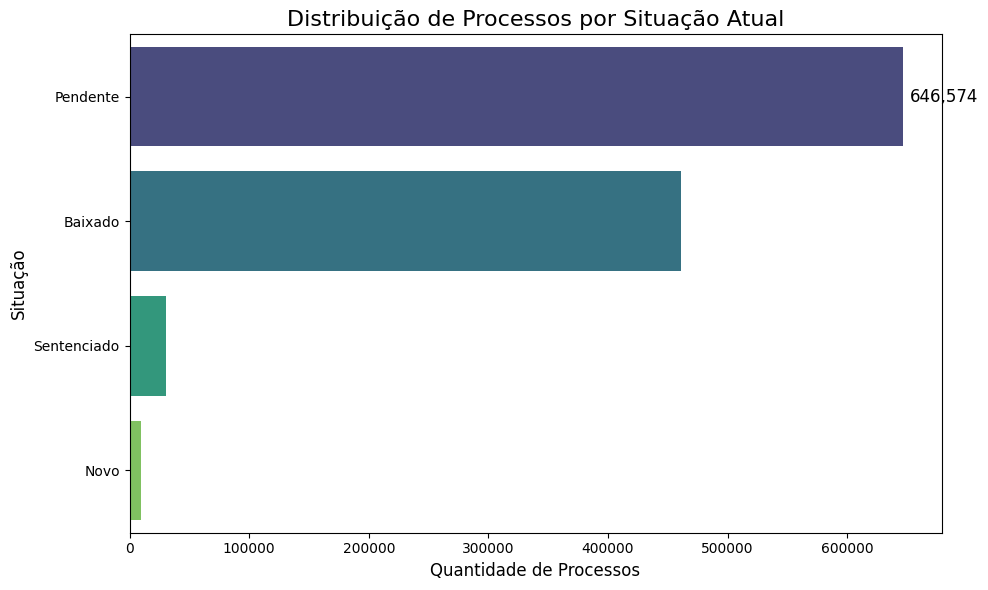

In [ ]:
# Importa as bibliotecas necessárias para o projeto
import pandas as pd
import os
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ======================================================================
# FASE 3: PREPARAÇÃO E VALIDAÇÃO DA BASE DE DADOS MESTRA
# ======================================================================

# --- ETAPA 1: SETUP E CARREGAMENTO DOS DADOS ---
# Comentário de Negócio: Garante o acesso aos dados brutos no Google Drive.
print("Montando o Google Drive...")
try:
    # Este comando abre uma janela de autenticação para conectar ao seu Google Drive
    drive.mount('/content/drive', force_remount=True)
    # Define o caminho da pasta onde os arquivos originais estão
    caminho_dados_brutos = "/content/drive/MyDrive/Projeto Final - CD/brutos"
    # Define o caminho da pasta onde os arquivos tratados serão salvos
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    # Cria a pasta de destino se ela não existir
    os.makedirs(caminho_dados_tratados, exist_ok=True)
except Exception as e:
    # Captura e exibe qualquer erro que ocorra durante a montagem do Drive
    print(f"Erro ao montar o Google Drive: {e}")
    exit() # Interrompe a execução se a montagem falhar

print("\n--- Carregando todos os arquivos de origem ---")
try:
    # Carrega cada arquivo CSV em uma tabela (DataFrame) do Pandas
    df_pendentes = pd.read_csv(os.path.join(caminho_dados_brutos, 'TJDFT_pendentes.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    df_novos = pd.read_csv(os.path.join(caminho_dados_brutos, 'TJDFT_novos.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    df_sentenciados = pd.read_csv(os.path.join(caminho_dados_brutos, 'TJDFT_setenciados.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    df_baixados = pd.read_csv(os.path.join(caminho_dados_brutos, 'TJDFT_baixados.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    df_pendentes15 = pd.read_csv(os.path.join(caminho_dados_brutos, 'TJDFT_pendentes15anos.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    print("-> Todos os arquivos carregados com sucesso.")
except FileNotFoundError as e:
    # Captura o erro se um arquivo não for encontrado no caminho especificado
    print(f"ERRO: Um dos arquivos não foi encontrado. Detalhes: {e}")
    exit()

# --- ETAPA 2: UNIFICAÇÃO INICIAL (PENDENTES + NOVOS) COM RECONCILIAÇÃO ---
# Comentário de Negócio: Unificamos as bases de 'pendentes' e 'novos' para criar o
#                      nosso universo inicial de processos, validando cada passo
#                      com um sumário de reconciliação.

print("\n\n==========================================================")
print("ETAPA 2: RECONCILIAÇÃO - PENDENTES + NOVOS")
print("==========================================================")
count_pendentes = len(df_pendentes)
count_novos = len(df_novos)
total_antes_juncao = count_pendentes + count_novos
print(f"Total de registros em 'Pendentes': {count_pendentes:,.0f}".replace(",", "."))
print(f"Total de registros em 'Novos':     {count_novos:,.0f}".replace(",", "."))
print("-------------------------------------------------")
print(f"Total de registros ANTES da junção: {total_antes_juncao:,.0f}".replace(",", "."))

for df in [df_pendentes, df_novos, df_sentenciados, df_baixados, df_pendentes15]:
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('.', '_', regex=False)
df_novos.rename(columns={'data_de_referencia': 'data_de_ajuizamento'}, inplace=True)
df_pendentes['situacao_atual'] = 'Pendente'
df_novos['situacao_atual'] = 'Novo'
df_mestre = pd.concat([df_pendentes, df_novos], ignore_index=True, sort=False)
total_apos_juncao = len(df_mestre)
print(f"Total de registros APÓS a junção:  {total_apos_juncao:,.0f}".replace(",", "."))

duplicatas_para_analise = df_mestre[df_mestre.duplicated(subset=['processo', 'grau'], keep=False)]
total_processos_unicos_duplicados = duplicatas_para_analise.duplicated(subset=['processo', 'grau']).sum()
df_mestre['prioridade_status'] = df_mestre['situacao_atual'].apply(lambda x: 2 if x == 'Pendente' else 1)
df_mestre.sort_values(by=['processo', 'grau', 'prioridade_status'], ascending=[True, True, False], inplace=True)
df_mestre.drop_duplicates(subset=['processo', 'grau'], keep='first', inplace=True)
df_mestre.drop(columns=['prioridade_status'], inplace=True)
print(f"Total final após remoção de duplicatas: {len(df_mestre):,.0f}".replace(",", "."))


# --- ETAPA 3: ENRIQUECIMENTO COM 'SENTENCIADOS' E 'BAIXADOS' ---
# Comentário de Negócio: Enriquecemos a base mestra com os eventos de
#                      sentença e baixa, validando a integridade da junção.
print("\n\n==========================================================")
print("ETAPA 3: ENRIQUECIMENTO COM SENTENCIADOS E BAIXADOS")
print("==========================================================")
df_sentenciados.rename(columns={'data_de_referencia': 'data_da_sentenca'}, inplace=True)
df_baixados.rename(columns={'data_de_referencia': 'data_da_baixa'}, inplace=True)
df_sentenciados['data_da_sentenca'] = pd.to_datetime(df_sentenciados['data_da_sentenca'], errors='coerce', dayfirst=True)
df_baixados['data_da_baixa'] = pd.to_datetime(df_baixados['data_da_baixa'], errors='coerce', dayfirst=False)
df_sentenciados_add = df_sentenciados[['processo', 'grau', 'data_da_sentenca']].drop_duplicates(subset=['processo', 'grau'])
df_baixados_add = df_baixados[['processo', 'grau', 'data_da_baixa']].drop_duplicates(subset=['processo', 'grau'])

df_mestre = pd.merge(df_mestre, df_sentenciados_add, on=['processo', 'grau'], how='left')
df_mestre = pd.merge(df_mestre, df_baixados_add, on=['processo', 'grau'], how='left')

df_mestre.loc[df_mestre['data_da_sentenca'].notna(), 'situacao_atual'] = 'Sentenciado'
df_mestre.loc[df_mestre['data_da_baixa'].notna(), 'situacao_atual'] = 'Baixado'
print(f"-> Base Mestra enriquecida e status final atualizado.")


# --- ETAPA 4: REMOÇÃO DE OUTLIERS E SALVAMENTO FINAL ---
# Comentário de Negócio: Identificamos os processos com mais de 15 anos,
#                      removemos esses outliers para não distorcer as métricas,
#                      e salvamos a base mestra final, pronta para a análise.
print("\n--- ETAPA 4: REMOÇÃO DE OUTLIERS E SALVAMENTO FINAL ---")
# Primeiro, adicionamos a flag para identificar os outliers
processos_15_anos = df_pendentes15['processo'].tolist()
df_mestre['mais_15_anos'] = df_mestre['processo'].isin(processos_15_anos)
print(f"-> {df_mestre['mais_15_anos'].sum()} processos foram sinalizados como outliers (+15 anos).")

# Guarda a contagem original para comparação
registros_antes_outlier = len(df_mestre)
# Filtra o DataFrame, mantendo apenas as linhas onde a flag 'mais_15_anos' é False
df_mestre = df_mestre[df_mestre['mais_15_anos'] == False]
registros_removidos = registros_antes_outlier - len(df_mestre)
print(f"-> {registros_removidos} registros de outliers foram removidos.")

# Após a remoção, a coluna de flag se torna desnecessária e é excluída
df_mestre = df_mestre.drop(columns=['mais_15_anos'])
print("-> Coluna 'mais_15_anos' removida da tabela final.")

# Salva o arquivo final
nome_arquivo_final = 'base_mestre.csv'
caminho_arquivo_final = os.path.join(caminho_dados_tratados, nome_arquivo_final)
df_mestre.to_csv(caminho_arquivo_final, sep=';', encoding='utf-8-sig', index=False)
print(f"\n-> Base final e sem outliers salva em: '{caminho_arquivo_final}'")


# ======================================================================
# COMPLEMENTO: AVALIAÇÃO E VISUALIZAÇÃO DA BASE MESTRA FINAL
# ======================================================================
print("\n\n--- INICIANDO AVALIAÇÃO DA BASE MESTRA FINAL (SEM OUTLIERS) ---")

# Carrega a base de dados que acabamos de salvar para a avaliação
df_final = pd.read_csv(caminho_arquivo_final, sep=';', encoding='utf-8-sig', low_memory=False)
df_final['data_de_ajuizamento'] = pd.to_datetime(df_final['data_de_ajuizamento'], errors='coerce')

# 1. TESTE DE INTEGRIDADE: VERIFICAÇÃO DE DUPLICATAS
print("\n1. Verificando a integridade (duplicatas)...")
duplicatas = df_final[df_final.duplicated(subset=['processo', 'grau'], keep=False)]
if duplicatas.empty:
    print("✅ Teste de Integridade Aprovado: Nenhuma duplicata encontrada na base final.")
else:
    print(f"❌ Teste de Integridade Falhou: Foram encontradas {len(duplicatas)} linhas duplicadas.")

# 2. DADOS DEMONSTRATIVOS GERAIS (DETALHADO)
print("\n2. Resumo Geral e Detalhado da Base de Dados Final:")
print(f"   - Total de registros (processos/instância) únicos: {len(df_final)}")
print(f"   - Total de colunas disponíveis: {len(df_final.columns)}")
if 'data_de_ajuizamento' in df_final.columns and not df_final['data_de_ajuizamento'].isnull().all():
    print(f"   - Período dos dados (data de ajuizamento): de {df_final['data_de_ajuizamento'].min().year} a {df_final['data_de_ajuizamento'].max().year}")

# 3. DISTRIBUIÇÃO POR SITUAÇÃO ATUAL (GRÁFICO)
print("\n3. Distribuição dos Processos por Situação Atual:")
plt.figure(figsize=(10, 6))
ax = sns.countplot(y=df_final['situacao_atual'], order=df_final['situacao_atual'].value_counts().index, palette='viridis')
ax.set_title('Distribuição de Processos por Situação Atual', fontsize=16)
ax.set_xlabel('Quantidade de Processos', fontsize=12); ax.set_ylabel('Situação', fontsize=12)
ax.bar_label(ax.containers[0], fmt='{:,.0f}'.format, fontsize=12, padding=5)
plt.tight_layout(); plt.show()

## Etapa 2.2: Higienização e Criação da Dimensão de Processos

In [ ]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

# ======================================================================
# FASE FINAL: ANÁLISE DIMENSIONAL TABELA MESTRA - CRIAÇÃO DIM_PROCESSOS
# Objetivo: Realizar a limpeza final da tabela de dimensão de processos
#           e identificar os campos-chave para os relacionamentos no BI.
# ======================================================================

# --- ETAPA 1: CARREGAMENTO DA BASE MESTRA JÁ SEM OUTLIERS ---
print("Montando o Google Drive e carregando a base mestra pré-limpa...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"

    nome_base_final = 'base_mestre.csv'
    caminho_base_final = os.path.join(caminho_dados_tratados, nome_base_final)

    df_mestre = pd.read_csv(caminho_base_final, sep=';', encoding='utf-8-sig', low_memory=False)
    print(f"-> Base mestra (sem outliers) carregada com {len(df_mestre):,} registros.".replace(",", "."))

except Exception as e:
    print(f"ERRO: Não foi possível carregar a base mestra. Detalhes: {e}")
    exit()

# --- ETAPA 2: SELEÇÃO DAS COLUNAS FINAIS ---
# Comentário: Selecionamos apenas as colunas que serão efetivamente utilizadas.
# A coluna 'mais_15_anos' já foi removida no script anterior.
colunas_para_manter = [
    'processo', 'grau', 'codigo_da_ultima_classe', 'codigo_orgao', 'id_municipio',
    'nome_orgao', 'municipio', 'situacao_atual', 'procedimento',
    'data_de_ajuizamento', 'data_da_sentenca', 'data_da_baixa', 'data_da_ultima_movimentacao'
]

# Cria o DataFrame final apenas com as colunas de interesse
df_final = df_mestre[colunas_para_manter].copy()
print(f"\n-> Colunas desnecessárias removidas. A tabela agora tem {len(df_final.columns)} colunas.")


# --- ETAPA 3: ANÁLISE E TRATAMENTO DE VALORES NULOS ---
# Comentário para Apresentação:
# "Realizamos uma análise de valores nulos nas colunas selecionadas para
#  identificar e tratar inconsistências que poderiam afetar os cálculos."

print("\n--- Análise de Valores Nulos nas Colunas Finais ---")
print("Contagem de valores nulos ANTES do tratamento:")
print(df_final.isnull().sum().sort_values(ascending=False).to_markdown())

colunas_criticas = ['data_de_ajuizamento', 'nome_orgao']
registros_antes_nulos = len(df_final)

# .dropna() remove as linhas que contêm valores nulos nas colunas especificadas
df_final.dropna(subset=colunas_criticas, inplace=True)

registros_removidos_nulos = registros_antes_nulos - len(df_final)
print(f"\n-> Tratamento de nulos concluído. Foram removidos {registros_removidos_nulos} registros sem data de ajuizamento ou órgão julgador.")


# --- ETAPA 4: IDENTIFICAÇÃO DOS CAMPOS DIMENSIONAIS ---
# Comentário para Apresentação:
# "Com a tabela de processos limpa, identificamos formalmente quais colunas
#  servirão como chaves estrangeiras para conectar esta tabela com as
#  outras tabelas de dimensão (legendas) no nosso modelo de BI."

print("\n--- Apontando os Campos para Conexão com Outras Dimensões ---")

# Dicionário que mapeia a chave na tabela de processos para a sua tabela de dimensão
mapa_dimensional = {
    "codigo_da_ultima_classe": "dim_classes.csv",
    "codigo_orgao": "dim_orgaos.csv",
    # O 'id_municipio' poderia se conectar a uma futura 'dimensao_municipios'
    "id_municipio": "(Futura) dim_municipios.csv"
}

print("As seguintes colunas nesta tabela servirão como 'pontes' para suas respectivas tabelas de legenda:")
for campo, dimensao in mapa_dimensional.items():
    if campo in df_final.columns:
        print(f"- A coluna '{campo}' se conectará com a tabela '{dimensao}'.")


# --- ETAPA 5: SALVAMENTO DA TABELA MESTRA HIGIENIZADA ---
# Comentário para Apresentação:
# "Ao final, salvamos a Tabela Mestra final, limpa e otimizada, pronta para ser
#  a Tabela de Dimensão de Processos no nosso ambiente de BI."

print(f"\nDimensões finais da Tabela de Dimensão de Processos: {df_final.shape}")

# Salva o arquivo final com o nome definitivo
nome_arquivo_dim_processos = 'dim_processos.csv'
caminho_arquivo_dim_processos = os.path.join(caminho_dados_tratados, nome_arquivo_dim_processos)
df_final.to_csv(caminho_arquivo_dim_processos, sep=';', encoding='utf-8-sig', index=False)
print(f"\n-> Tabela Mestra (Dimensão de Processos) final salva em: '{caminho_arquivo_dim_processos}'")

Montando o Google Drive e carregando a base mestra pré-limpa...
Mounted at /content/drive
-> Base mestra (sem outliers) carregada com 1.147.851 registros.

-> Colunas desnecessárias removidas. A tabela agora tem 13 colunas.

--- Análise de Valores Nulos nas Colunas Finais ---
Contagem de valores nulos ANTES do tratamento:
|                             |      0 |
|:----------------------------|-------:|
| data_da_sentenca            | 961096 |
| data_da_baixa               | 686840 |
| data_da_ultima_movimentacao | 428674 |
| grau                        |      0 |
| processo                    |      0 |
| id_municipio                |      0 |
| codigo_orgao                |      0 |
| codigo_da_ultima_classe     |      0 |
| nome_orgao                  |      0 |
| procedimento                |      0 |
| situacao_atual              |      0 |
| municipio                   |      0 |
| data_de_ajuizamento         |      0 |

-> Tratamento de nulos concluído. Foram removidos 0 registro

## Etapa 2.3: Geração da Tabela Fato de Movimentos

In [ ]:
# Importa as bibliotecas necessárias para o projeto
import pandas as pd
import os
import re
from google.colab import drive

# ======================================================================
# FASE DE MODELAGEM: CRIAÇÃO DA TABELA FATO DE MOVIMENTOS
# ======================================================================

# --- ETAPA 1: CARREGAMENTO DOS ARQUIVOS NECESSÁRIOS ---
# Comentário: Carregamos a base de processos já limpa e sem outliers.
#             Também carregamos a base reconciliada original para buscar as
#             colunas de movimento que foram removidas na higienização.

print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
except Exception as e:
    print(f"Erro ao montar o Google Drive: {e}")
    exit()

print("\nCarregando arquivos...")
try:
    # *** CORREÇÃO APLICADA AQUI: Usando o nome do arquivo que você confirmou ***
    nome_base_limpa = 'base_mestre.csv'
    caminho_base_limpa = os.path.join(caminho_dados_tratados, nome_base_limpa)
    df_processos_limpos = pd.read_csv(caminho_base_limpa, sep=';', encoding='utf-8-sig', low_memory=False)
    print(f"-> Base limpa '{nome_base_limpa}' carregada com {len(df_processos_limpos):,} registros.".replace(",", "."))

    # Carrega a base original para buscar as colunas de movimento
    nome_base_original = 'base_mestre.csv'
    caminho_base_original = os.path.join(caminho_dados_tratados, nome_base_original)
    df_mestre_original = pd.read_csv(caminho_base_original, sep=';', encoding='utf-8-sig', low_memory=False)
    print(f"-> Base original '{nome_base_original}' carregada para consulta.")

except FileNotFoundError as e:
     print(f"ERRO: O arquivo '{e.filename}' não foi encontrado. Verifique se ambos os arquivos existem na pasta /tratados.")
     exit()
except Exception as e:
    print(f"ERRO: Não foi possível carregar os arquivos. Detalhes: {e}")
    exit()

# --- ETAPA 2: PREPARAÇÃO PARA EXTRAÇÃO ---
# Comentário: Juntamos as colunas de movimento da base original com a nossa
#             lista de processos limpa, garantindo que só analisaremos os
#             movimentos dos processos que não são outliers.

# Normaliza colunas da base original para a junção
df_mestre_original.columns = df_mestre_original.columns.str.lower().str.replace(' ', '_').str.replace('.', '_', regex=False)

# Colunas que precisamos da base original
colunas_movimento_para_buscar = ['processo', 'grau', 'data_da_decisao:_situacao:_movimento', 'data_do_julgamento:_situacao:_movimento']

# Usa um 'merge' para adicionar as colunas de movimento à nossa base limpa
df_mestre_para_analise = pd.merge(
    df_processos_limpos[['processo', 'grau']],
    df_mestre_original[colunas_movimento_para_buscar],
    on=['processo', 'grau'],
    how='left'
)
print("\n-> Colunas de movimento adicionadas à base de análise limpa.")


# --- ETAPA 3: EXTRAÇÃO E TRANSFORMAÇÃO DOS MOVIMENTOS ---
print("\n--- Criando a tabela de movimentos com categorização ---")
col_decisao = 'data_da_decisao:_situacao:_movimento'
col_julgamento = 'data_do_julgamento:_situacao:_movimento'

def parsear_movimentos(texto_movimentos):
    if not isinstance(texto_movimentos, str) or texto_movimentos == '{}':
        return []
    return re.findall(r'(\d{8}):(\d+):(\d+)', texto_movimentos)

# Processa os movimentos de DECISÃO/TRAMITAÇÃO
df_decisao = df_mestre_para_analise[['processo', 'grau', col_decisao]].dropna(subset=[col_decisao]).copy()
df_decisao['lista_movimentos'] = df_decisao[col_decisao].apply(parsear_movimentos)
df_decisao['tipo_de_movimento'] = 'Decisão/Tramitação'
df_decisao_exp = df_decisao.explode('lista_movimentos').dropna(subset=['lista_movimentos'])

# Processa os movimentos de JULGAMENTO
df_julgamento = df_mestre_para_analise[['processo', 'grau', col_julgamento]].dropna(subset=[col_julgamento]).copy()
df_julgamento['lista_movimentos'] = df_julgamento[col_julgamento].apply(parsear_movimentos)
df_julgamento['tipo_de_movimento'] = 'Julgamento'
df_julgamento_exp = df_julgamento.explode('lista_movimentos').dropna(subset=['lista_movimentos'])

# Concatena os dois tipos de movimento em uma única tabela
df_movimentos = pd.concat([df_decisao_exp, df_julgamento_exp], ignore_index=True)

# Cria as colunas finais
df_movimentos['data_movimento'] = pd.to_datetime(df_movimentos['lista_movimentos'].str[0], format='%Y%m%d', errors='coerce')
df_movimentos['codigo_situacao'] = df_movimentos['lista_movimentos'].str[1]
df_movimentos['codigo_movimento'] = df_movimentos['lista_movimentos'].str[2]

df_movimentos = df_movimentos[['processo', 'grau', 'tipo_de_movimento', 'data_movimento', 'codigo_situacao', 'codigo_movimento']]
print(f"-> Tabela de movimentos categorizada criada com {len(df_movimentos)} eventos.")


# --- ETAPA 4: SALVAMENTO ---
nome_arquivo_movimentos = 'fato_movimentos.csv'
caminho_movimentos = os.path.join(caminho_dados_tratados, nome_arquivo_movimentos)
df_movimentos.to_csv(caminho_movimentos, sep=';', encoding='utf-8-sig', index=False)
print(f"\n-> Tabela Fato de Movimentos salva com sucesso em: '{caminho_movimentos}'")

Montando o Google Drive...
Mounted at /content/drive

Carregando arquivos...
-> Base limpa 'base_mestre.csv' carregada com 1.147.851 registros.
-> Base original 'base_mestre.csv' carregada para consulta.

-> Colunas de movimento adicionadas à base de análise limpa.

--- Criando a tabela de movimentos com categorização ---
-> Tabela de movimentos categorizada criada com 3439384 eventos.

-> Tabela Fato de Movimentos salva com sucesso em: '/content/drive/MyDrive/Projeto Final - CD/tratados/fato_movimentos.csv'


# Fase 3: Modelagem Star Schema (Geração de Dimensões)

## Etapa 3.1: Geração das Tabelas Fato e Dimensões

In [ ]:
# =================================================================================
# SCRIPT MESTRE: GERAÇÃO COMPLETA DO MODELO STAR SCHEMA OTIMIZADO PARA BI
# Data: 19/10/2025 (Atualizado para sobrescrever a fato_movimentos)
# =================================================================================

# --- ETAPA 1: SETUP E CARREGAMENTO DOS DADOS BASE ---
import pandas as pd
import os
from google.colab import drive

print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
except Exception as e:
    print(f"Erro ao montar o Google Drive: {e}")
    exit()

print("\nCarregando as tabelas base para o processo de ETL...")
try:
    # Carrega os arquivos que são a base para a transformação
    df_processos = pd.read_csv(os.path.join(caminho_dados_tratados, 'dim_processos.csv'), sep=';', encoding='utf-8-sig')
    df_movimentos = pd.read_csv(os.path.join(caminho_dados_tratados, 'fato_movimentos.csv'), sep=';', encoding='utf-8-sig')
    # Carrega a base mestra, necessária para a tabela ponte de assuntos
    df_mestre = pd.read_csv(os.path.join(caminho_dados_tratados, 'base_mestre.csv'), sep=';', encoding='utf-8-sig', low_memory=False)
    print("-> Tabelas base (Processos, Movimentos, Mestre) carregadas com sucesso.")

    # retira colina codigo_orgao e id_municipio, pois já tem o nome do orgão e municipio que será dimensionado
    if 'codigo_orgao' in df_processos.columns:
        df_processos.drop(columns=['codigo_orgao'], inplace=True)
        print("-> Coluna desnecessária 'codigo_orgao' removida com sucesso.")
    if 'id_municipio' in df_processos.columns:
        df_processos.drop(columns=['id_municipio'], inplace=True)
        print("-> Coluna de ID pré-existente 'id_municipio' removida de df_processos para recriação padronizada.")

except Exception as e:
    print(f"ERRO: Não foi possível carregar um dos arquivos base. Verifique se 'dim_processos.csv', 'fato_movimentos.csv' e 'base_mestre.csv' existem. Detalhes: {e}")
    exit()


# =================================================================================
# --- ETAPA 2: CRIAÇÃO DINÂMICA DA DIMENSÃO TEMPO ---
# =================================================================================
print("\n--- Gerando a Dimensão Tempo de forma dinâmica ---")
colunas_de_data = []
for col in ['data_de_ajuizamento', 'data_da_sentenca', 'data_da_baixa', 'data_da_ultima_movimentacao']:
    if col in df_processos.columns:
        colunas_de_data.append(df_processos[col])
if 'data_movimento' in df_movimentos.columns:
    colunas_de_data.append(df_movimentos['data_movimento'])
todas_as_datas = pd.concat(colunas_de_data, ignore_index=True)
todas_as_datas = pd.to_datetime(todas_as_datas, errors='coerce')
data_inicio = todas_as_datas.min().floor('D')
data_fim = todas_as_datas.max().ceil('D')
print(f"-> Intervalo de datas detectado nos dados: de {data_inicio.date()} a {data_fim.date()}.")
datas = pd.date_range(start=data_inicio, end=data_fim)
df_dim_tempo = pd.DataFrame({'data_completa': datas})
df_dim_tempo['ano'] = df_dim_tempo['data_completa'].dt.year
df_dim_tempo['trimestre'] = df_dim_tempo['data_completa'].dt.quarter
df_dim_tempo['mes'] = df_dim_tempo['data_completa'].dt.month
df_dim_tempo['nome_mes'] = df_dim_tempo['data_completa'].dt.strftime('%B')
df_dim_tempo['dia'] = df_dim_tempo['data_completa'].dt.day
df_dim_tempo['dia_da_semana'] = df_dim_tempo['data_completa'].dt.dayofweek
df_dim_tempo['nome_dia_da_semana'] = df_dim_tempo['data_completa'].dt.strftime('%A')
df_dim_tempo['id_data'] = df_dim_tempo['data_completa'].dt.strftime('%Y%m%d').astype(int)
df_dim_tempo = df_dim_tempo[['id_data', 'data_completa', 'ano', 'trimestre', 'mes', 'nome_mes', 'dia', 'dia_da_semana', 'nome_dia_da_semana']]
mapa_meses = {'January': 'Janeiro', 'February': 'Fevereiro', 'March': 'Março', 'April': 'Abril', 'May': 'Maio', 'June': 'Junho', 'July': 'Julho', 'August': 'Agosto', 'September': 'Setembro', 'October': 'Outubro', 'November': 'Novembro', 'December': 'Dezembro'}
mapa_dias = {'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira', 'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}
df_dim_tempo['nome_mes'] = df_dim_tempo['nome_mes'].map(mapa_meses)
df_dim_tempo['nome_dia_da_semana'] = df_dim_tempo['nome_dia_da_semana'].map(mapa_dias)
print(f"-> Dimensão Tempo criada com sucesso para o período de {data_inicio.date()} a {data_fim.date()}.")
linha_desconhecida = pd.DataFrame([
    {'id_data': 0, 'data_completa': pd.NaT, 'ano': 1900, 'trimestre': 0,
     'mes': 0, 'nome_mes': 'N/A', 'dia': 0, 'dia_da_semana': 0,
     'nome_dia_da_semana': 'N/A'}
])
df_dim_tempo = pd.concat([linha_desconhecida, df_dim_tempo], ignore_index=True)
print("-> Linha de 'Membro Desconhecido' (ID 0) adicionada à Dimensão Tempo.")

# --- ETAPA 3: CRIAÇÃO DA TABELA PONTE PROCESSO-ASSUNTO ---
print("\n--- Gerando a Tabela Ponte Processo-Assunto ---")
coluna_assuntos = 'codigos_assuntos'
if coluna_assuntos in df_mestre.columns:
    df_para_explodir = df_mestre[['processo', 'grau', coluna_assuntos]].copy()
    df_para_explodir.dropna(subset=[coluna_assuntos], inplace=True)
    def extrair_codigos_assunto(texto_assuntos):
        if not isinstance(texto_assuntos, str): return []
        return [codigo for codigo in texto_assuntos.replace('{', '').replace('}', '').replace(' ', '').split(',') if codigo]
    df_para_explodir['lista_assuntos'] = df_para_explodir[coluna_assuntos].apply(extrair_codigos_assunto)
    df_ponte_assuntos = df_para_explodir.explode('lista_assuntos')
    df_ponte_assuntos.rename(columns={'lista_assuntos': 'id_assunto'}, inplace=True)
    df_ponte_assuntos = df_ponte_assuntos[df_ponte_assuntos['id_assunto'] != '']
    df_ponte_assuntos = df_ponte_assuntos[['processo', 'grau', 'id_assunto']]
    print(f"-> Tabela Ponte criada com {len(df_ponte_assuntos):,} relações processo-assunto.")
else:
    print(f"AVISO: A coluna '{coluna_assuntos}' não foi encontrada na base_mestre. A tabela ponte não será gerada.")
    df_ponte_assuntos = pd.DataFrame(columns=['processo', 'grau', 'id_assunto'])


# --- ETAPA 4: FUNÇÃO AUXILIAR PARA DIMENSIONALIZAR ---
def dimensionalizar_coluna(df_principal, nome_coluna):
    valores_unicos = df_principal[nome_coluna].dropna().unique()
    df_dimensao = pd.DataFrame({f'id_{nome_coluna}': range(1, len(valores_unicos) + 1), f'dsc_{nome_coluna}': valores_unicos})
    mapa = pd.Series(df_dimensao[f'id_{nome_coluna}'].values, index=df_dimensao[f'dsc_{nome_coluna}']).to_dict()
    df_principal[nome_coluna] = df_principal[nome_coluna].map(mapa)
    df_principal.rename(columns={nome_coluna: f'id_{nome_coluna}'}, inplace=True)
    print(f"-> Coluna '{nome_coluna}' dimensionalizada.")
    return df_principal, df_dimensao


# --- ETAPA 5: APLICAR A DIMENSIONALIZAÇÃO ---
print("\n--- Iniciando a dimensionalização das colunas ---")
df_processos, df_dim_orgao = dimensionalizar_coluna(df_processos, 'nome_orgao')
df_processos, df_dim_municipio = dimensionalizar_coluna(df_processos, 'municipio')
df_processos, df_dim_situacao = dimensionalizar_coluna(df_processos, 'situacao_atual')
df_processos, df_dim_procedimento = dimensionalizar_coluna(df_processos, 'procedimento')
df_movimentos, df_dim_tipo_movimento = dimensionalizar_coluna(df_movimentos, 'tipo_de_movimento')


# --- ETAPA 6: PROCESSAMENTO DAS CHAVES DE DATA ---
print("\n--- Criando chaves numéricas para a Dimensão Tempo ---")
for col_data in ['data_de_ajuizamento', 'data_da_sentenca', 'data_da_baixa', 'data_da_ultima_movimentacao']:
    if col_data in df_processos.columns:
        col_id = f'id_{col_data}'
        df_processos[col_data] = pd.to_datetime(df_processos[col_data], errors='coerce')
        df_processos[col_id] = df_processos[col_data].dt.strftime('%Y%m%d')
        df_processos[col_id] = df_processos[col_id].fillna(0)
        df_processos[col_id] = df_processos[col_id].astype(int)
df_movimentos['data_movimento'] = pd.to_datetime(df_movimentos['data_movimento'], errors='coerce')
df_movimentos['id_data_movimento'] = df_movimentos['data_movimento'].dt.strftime('%Y%m%d')
df_movimentos['id_data_movimento'] = df_movimentos['id_data_movimento'].fillna(0)
df_movimentos['id_data_movimento'] = df_movimentos['id_data_movimento'].astype(int)
df_processos.drop(columns=['data_de_ajuizamento', 'data_da_sentenca', 'data_da_baixa', 'data_da_ultima_movimentacao'], inplace=True, errors='ignore')
df_movimentos.drop(columns=['data_movimento'], inplace=True, errors='ignore')
print("-> Chaves de data criadas e colunas originais removidas.")


# =================================================================================
# --- ETAPA 7: ENRIQUECIMENTO DA TABELA FATO (CÓDIGO ALTERADO) ---
# Em vez de criar um novo dataframe 'fato_unificada', enriquecemos
# o dataframe 'df_movimentos' diretamente.
# =================================================================================
print("\n--- Enriquecendo a Tabela Fato (df_movimentos) ---")
# O merge agora adiciona as colunas de 'df_processos' em 'df_movimentos'
# e sobrescreve o dataframe original 'df_movimentos'.
df_movimentos = pd.merge(df_movimentos, df_processos, on=['processo', 'grau'], how='left')
print(f"-> Merge concluído. A Tabela Fato final possui {len(df_movimentos):,} linhas.")


# =================================================================================
# --- ETAPA 8: SALVAMENTO DE TODOS OS ARQUIVOS FINAIS (CÓDIGO ALTERADO) ---
# A tabela fato principal agora é 'df_movimentos', que será salva
# como 'fato_movimentos.csv', substituindo o arquivo antigo.
# =================================================================================
print("\n--- Salvando todas as tabelas do modelo Star Schema ---")
tabelas_finais = {
    'fato_movimentos.csv': df_movimentos, # ALTERAÇÃO: Salva o dataframe enriquecido com o nome original
    'ponte_processo_assunto.csv': df_ponte_assuntos,
    'dim_tempo.csv': df_dim_tempo,
    'dim_orgao.csv': df_dim_orgao,
    'dim_municipio.csv': df_dim_municipio,
    'dim_situacao.csv': df_dim_situacao,
    'dim_procedimento.csv': df_dim_procedimento,
    'dim_tipo_movimento.csv': df_dim_tipo_movimento
}

for nome_arquivo, df in tabelas_finais.items():
    if not df.empty:
        caminho_final = os.path.join(caminho_dados_tratados, nome_arquivo)
        df.to_csv(caminho_final, sep=';', encoding='utf-8-sig', index=False)
        print(f"-> Arquivo '{nome_arquivo}' salvo com sucesso.")

print("\n\n✅ PROCESSO CONCLUÍDO! Seu modelo de dados completo foi gerado e atualizado na pasta 'tratados'.")

Montando o Google Drive...
Mounted at /content/drive

Carregando as tabelas base para o processo de ETL...
-> Tabelas base (Processos, Movimentos, Mestre) carregadas com sucesso.
-> Coluna desnecessária 'codigo_orgao' removida com sucesso.
-> Coluna de ID pré-existente 'id_municipio' removida de df_processos para recriação padronizada.

--- Gerando a Dimensão Tempo de forma dinâmica ---
-> Intervalo de datas detectado nos dados: de 1990-06-28 a 2025-12-06.
-> Dimensão Tempo criada com sucesso para o período de 1990-06-28 a 2025-12-06.
-> Linha de 'Membro Desconhecido' (ID 0) adicionada à Dimensão Tempo.

--- Gerando a Tabela Ponte Processo-Assunto ---
-> Tabela Ponte criada com 1,833,624 relações processo-assunto.

--- Iniciando a dimensionalização das colunas ---
-> Coluna 'nome_orgao' dimensionalizada.
-> Coluna 'municipio' dimensionalizada.
-> Coluna 'situacao_atual' dimensionalizada.
-> Coluna 'procedimento' dimensionalizada.
-> Coluna 'tipo_de_movimento' dimensionalizada.

--- Cri

# Fase 4: Validação e Diagnóstico Pós-Modelagem

## Etapa 4.1: Diagnóstico e Correção de Codificação (Encoding)

In [ ]:
# SCRIPT DE DIAGNÓSTICO DE CODIFICAÇÃO EM LOTE

!pip install chardet -q # Instala a biblioteca silenciosamente

import chardet
import os
from google.colab import drive

print("Montando o Google Drive para inspecionar os arquivos...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_pasta = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    print(f"\n--- Analisando arquivos na pasta: '{caminho_pasta}' ---\n")

    # Lista todos os arquivos na pasta que terminam com .csv
    arquivos_csv = [f for f in os.listdir(caminho_pasta) if f.endswith('.csv')]

    for nome_arquivo in arquivos_csv:
        caminho_arquivo = os.path.join(caminho_pasta, nome_arquivo)
        try:
            with open(caminho_arquivo, 'rb') as f:
                raw_data = f.read(102400) # Lê os primeiros 100KB
                resultado = chardet.detect(raw_data)

            encoding = resultado['encoding']
            confianca = resultado['confidence']
            print(f"Arquivo: {nome_arquivo:<30} | Codificação Detectada: {encoding.upper():<10} | Confiança: {confianca:.0%}")
        except Exception as e:
            print(f"Não foi possível analisar o arquivo {nome_arquivo}. Erro: {e}")

except Exception as e:
    print(f"Ocorreu um erro: {e}")

Montando o Google Drive para inspecionar os arquivos...
Mounted at /content/drive

--- Analisando arquivos na pasta: '/content/drive/MyDrive/Projeto Final - CD/tratados' ---

Arquivo: base_mestre.csv                | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_processos.csv              | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: fato_movimentos.csv            | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_situacao.csv               | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_nome_orgao.csv             | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_orgao.csv                  | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_situacao_atual.csv         | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_tempo.csv                  | Codificação Detectada: UTF-8-SIG  | Confiança: 100%
Arquivo: dim_tipo_movimento.csv         | Codificação Detectada: UTF-8-SI

In [ ]:
# SCRIPT DE CORREÇÃO E PADRONIZAÇÃO DE CODIFICAÇÃO EM LOTE

!pip install chardet -q

import pandas as pd
import chardet
import os
from google.colab import drive

print("Montando o Google Drive para corrigir os arquivos...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_pasta = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    print(f"\n--- Padronizando arquivos na pasta: '{caminho_pasta}' para UTF-8-SIG ---\n")

    arquivos_csv = [f for f in os.listdir(caminho_pasta) if f.endswith('.csv')]

    for nome_arquivo in arquivos_csv:
        caminho_arquivo = os.path.join(caminho_pasta, nome_arquivo)
        try:
            # 1. Detecta a codificação original
            with open(caminho_arquivo, 'rb') as f:
                raw_data = f.read(102400)
                encoding_original = chardet.detect(raw_data)['encoding']

            # 2. Lê o arquivo usando a codificação detectada
            df = pd.read_csv(caminho_arquivo, sep=';', encoding=encoding_original, low_memory=False)

            # 3. Salva o arquivo de volta com a codificação padrão e correta
            df.to_csv(caminho_arquivo, sep=';', encoding='utf-8-sig', index=False)

            print(f"✅ Arquivo '{nome_arquivo}' lido como '{encoding_original.upper()}' e salvo como 'UTF-8-SIG'.")

        except Exception as e:
            print(f"❌ Falha ao processar o arquivo {nome_arquivo}. Erro: {e}")

except Exception as e:
    print(f"Ocorreu um erro geral: {e}")

Montando o Google Drive para corrigir os arquivos...
Mounted at /content/drive

--- Padronizando arquivos na pasta: '/content/drive/MyDrive/Projeto Final - CD/tratados' para UTF-8-SIG ---

✅ Arquivo 'base_mestre.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_processos.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'fato_movimentos.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_situacao.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_nome_orgao.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_orgao.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_situacao_atual.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_tempo.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_tipo_movimento.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_municipio.csv' lido como 'UTF-8-SIG' e salvo como 'UTF-8-SIG'.
✅ Arquivo 'dim_procedimento.c

## Etapa 4.2: Validação Final Pós-Correção

In [ ]:
# Importa as bibliotecas necessárias
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ======================================================================
# FASE DE VALIDAÇÃO FINAL: VISUALIZAÇÃO DAS TABELAS TRATADAS (VERSÃO CORRIGIDA)
# ======================================================================

# --- ETAPA 1: SETUP E CARREGAMENTO ---
print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
except Exception as e:
    print(f"Erro ao montar o Google Drive: {e}")
    exit()

# Lista completa de todos os arquivos finais que devem existir
arquivos_para_visualizar = [
    'fato_movimentos.csv',
    'dim_orgao.csv',
    'dim_municipio.csv',
    'dim_situacao.csv',
    'dim_procedimento.csv',
    'dim_classes.csv',
    'dim_assuntos_hierarquico.csv',
    'dim_movimentos.csv',
    'dim_tipo_movimento.csv',
    'ponte_processo_assunto.csv'
]

# --- ETAPA 2: CARREGAR E VISUALIZAR CADA TABELA ---
print("\n--- Exibindo o conteúdo das tabelas finais do modelo de BI ---")

for nome_arquivo in arquivos_para_visualizar:
    caminho_completo = os.path.join(caminho_dados_tratados, nome_arquivo)

    print(f"\n==========================================================")
    print(f"CONTEÚDO DO ARQUIVO: {nome_arquivo}")
    print(f"==========================================================")

    try:
        # =================================================================
        # CORREÇÃO APLICADA AQUI
        # Removemos a lógica condicional e usamos ';' como padrão para todos.
        # =================================================================
        separador = ';'

        # Carrega o arquivo CSV com o separador padronizado
        df = pd.read_csv(caminho_completo, sep=separador, encoding='utf-8-sig', low_memory=False)

        print(f"-> Dimensões: {df.shape[0]} linhas, {df.shape[1]} colunas.")
        print("-> Amostra dos dados:")
        print(df.head().to_markdown(index=False))

    except FileNotFoundError:
        print(f"ERRO: O arquivo '{nome_arquivo}' não foi encontrado na pasta '/tratados'. Verifique se ele foi criado/exportado.")
    except Exception as e:
        print(f"ERRO ao ler o arquivo '{nome_arquivo}': {e}")

Montando o Google Drive...
Mounted at /content/drive

--- Exibindo o conteúdo das tabelas finais do modelo de BI ---

CONTEÚDO DO ARQUIVO: fato_movimentos.csv
-> Dimensões: 3439384 linhas, 15 colunas.
-> Amostra dos dados:
| processo                  | grau   |   id_tipo_de_movimento |   codigo_situacao |   codigo_movimento |   id_data_movimento |   codigo_da_ultima_classe |   id_nome_orgao |   id_municipio |   id_situacao_atual |   id_procedimento |   id_data_de_ajuizamento |   id_data_da_sentenca |   id_data_da_baixa |   id_data_da_ultima_movimentacao |
|:--------------------------|:-------|-----------------------:|------------------:|-------------------:|--------------------:|--------------------------:|----------------:|---------------:|--------------------:|------------------:|-------------------------:|----------------------:|-------------------:|---------------------------------:|
| 0000001-04.2023.8.07.0003 | G1     |                      1 |                 9 |                

## Etapa 4.3: Diagnóstico de Arquivos Finais (Tipos e Nulos)

In [ ]:
# =================================================================================
# SCRIPT DE DIAGNÓSTICO DOS ARQUIVOS CSV NA PASTA /TRATADOS
#
# Descrição:
# Este script lista todos os arquivos .csv na pasta /tratados,
# e para cada um, exibe a contagem de linhas, os tipos de dados
# das colunas e a contagem de valores nulos em cada coluna.
# =================================================================================

import pandas as pd
import os
import io
from google.colab import drive

# --- ETAPA 1: SETUP E MONTAGEM DO DRIVE ---
print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    print(f"-> Google Drive montado. Lendo arquivos de: {caminho_dados_tratados}")
except Exception as e:
    print(f"ERRO CRÍTICO no setup do Drive: {e}")
    exit()

# --- ETAPA 2: LISTAR E ANALISAR CADA CSV ---
try:
    arquivos_na_pasta = os.listdir(caminho_dados_tratados)
    arquivos_csv = [f for f in arquivos_na_pasta if f.endswith('.csv')]

    if not arquivos_csv:
        print("\nNenhum arquivo .csv encontrado na pasta /tratados.")
        exit()

    print(f"\nEncontrados {len(arquivos_csv)} arquivos .csv. Iniciando análise...")

    for nome_arquivo in arquivos_csv:
        caminho_completo = os.path.join(caminho_dados_tratados, nome_arquivo)
        print("\n" + "="*60)
        print(f"Analisando Arquivo: {nome_arquivo}")
        print("="*60)

        try:
            # Usamos low_memory=False para evitar erros de tipo misto na leitura inicial
            df = pd.read_csv(caminho_completo, sep=';', encoding='utf-8-sig', low_memory=False)

            print(f"-> Total de Linhas: {len(df)}")

            # Captura a saída do df.info() para exibir tipos e nulos de forma compacta
            buffer = io.StringIO()
            df.info(buf=buffer)
            info_str = buffer.getvalue()

            print("\n--- Informações das Colunas (Tipos e Contagem Não-Nula) ---")
            print(info_str)

            # Exibe contagem específica de NULOS (NaN)
            print("\n--- Contagem Específica de Nulos (NaN/NaT) ---")
            contagem_nulos = df.isnull().sum()

            # Filtra para mostrar apenas colunas que TÊM nulos
            nulos_presentes = contagem_nulos[contagem_nulos > 0]

            if nulos_presentes.empty:
                print("Nenhuma coluna com valores nulos encontrada. Ótimo!")
            else:
                print("Colunas com valores nulos:")
                print(nulos_presentes)

        except Exception as e_inner:
            print(f"ERRO ao ler ou processar o arquivo '{nome_arquivo}': {e_inner}")

except Exception as e:
    print(f"ERRO ao listar arquivos na pasta /tratados: {e}")

Montando o Google Drive...
Mounted at /content/drive
-> Google Drive montado. Lendo arquivos de: /content/drive/MyDrive/Projeto Final - CD/tratados

Encontrados 15 arquivos .csv. Iniciando análise...

Analisando Arquivo: base_mestre.csv
-> Total de Linhas: 1147851

--- Informações das Colunas (Tipos e Contagem Não-Nula) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147851 entries, 0 to 1147850
Data columns (total 41 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   tribunal                                 1147851 non-null  object 
 1   grau                                     1147851 non-null  object 
 2   uf                                       1147851 non-null  object 
 3   municipio                                1147851 non-null  object 
 4   nome_orgao                               1147851 non-null  object 
 5   ano                                      1147851 non

# Fase 5: Geração do Script de Carga (SQL Dump)

In [ ]:
# =================================================================================
# SCRIPT DE CRIAÇÃO DE DUMP DE CARGA COMPLETO (VERSÃO FINAL LIMPA)
# DESCRIÇÃO: Este script carrega TODOS os dados tratados e gera um dump SQL
#            para carga completa no MySQL, SEM FILTRAGEM PRÉVIA POR ANO.
# =================================================================================

import pandas as pd
import os
from google.colab import drive
from numpy import int64, float64

# --- ETAPA 1: SETUP E MONTAGEM DO DRIVE ---
print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    print("-> Google Drive montado com sucesso.")
except Exception as e:
    print(f"ERRO CRÍTICO no setup do Drive: {e}")
    exit()

# --- ETAPA 2: CARGA DOS DADOS COMPLETOS ---
print("\n--- Carregando o conjunto de dados completo do Drive ---")
try:
    # Carrega a tabela fato completa (resultado do Script Mestre)
    df_fato_completa = pd.read_csv(os.path.join(caminho_dados_tratados, 'fato_movimentos.csv'), sep=';', encoding='utf-8-sig', low_memory=False) # low_memory=False para evitar aviso de tipo
    # Carrega a tabela ponte completa
    df_ponte_completa = pd.read_csv(os.path.join(caminho_dados_tratados, 'ponte_processo_assunto.csv'), sep=';', encoding='utf-8-sig')
    print("-> Tabelas 'fato_movimentos.csv' e 'ponte_processo_assunto.csv' carregadas.")

    # Dicionário com todas as dimensões a serem carregadas
    dimensoes_para_carregar = {
        'dim_tempo': 'dim_tempo.csv',
        'dim_orgao': 'dim_orgao.csv',
        'dim_municipio': 'dim_municipio.csv',
        'dim_situacao_atual': 'dim_situacao_atual.csv', # Nome correto do arquivo gerado
        'dim_procedimento': 'dim_procedimento.csv',
        'dim_tipo_de_movimento': 'dim_tipo_de_movimento.csv', # Nome correto do arquivo gerado
        'dim_classes': 'dim_classes.csv',
        'dim_movimentos': 'dim_movimentos.csv',
        'dim_assuntos_hierarquico': 'dim_assuntos_hierarquico.csv'
    }
    dataframes_dimensoes = {}
    print("-> Carregando tabelas de dimensão...")
    for nome_tabela_db, nome_arquivo in dimensoes_para_carregar.items():
        caminho_arquivo = os.path.join(caminho_dados_tratados, nome_arquivo)
        try:
            # Carrega o CSV para um dataframe
            df_dim = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig')
            # Armazena o dataframe usando o nome da TABELA NO BANCO como chave
            dataframes_dimensoes[nome_tabela_db] = df_dim
            print(f"   - '{nome_arquivo}' carregado.")
        except FileNotFoundError:
            print(f"   - AVISO: Arquivo '{nome_arquivo}' não encontrado.")
        except Exception as e_inner:
             print(f"   - ERRO ao carregar '{nome_arquivo}': {e_inner}")

except Exception as e:
    exit(f"ERRO INESPERADO ao carregar os dados: {e}")

# --- ETAPA 3: FUNÇÃO PARA GERAR O SCRIPT DE CARGA SQL ---
def gerar_inserts_fatiados(dataframe, nome_tabela_db, tamanho_fatia=500):
    """Gera comandos SQL (TRUNCATE + INSERTs) para um DataFrame."""
    # Corrige nome da tabela se necessário (Ex: dim_situacao_atual -> dim_situacao no DB)
    if nome_tabela_db == 'dim_situacao_atual': nome_tabela_db = 'dim_situacao'
    if nome_tabela_db == 'dim_tipo_de_movimento': nome_tabela_db = 'dim_tipo_movimento'

    comandos_sql = [f"-- CARGA DA TABELA: {nome_tabela_db}", f"TRUNCATE TABLE `{nome_tabela_db}`;"]
    if dataframe is None or dataframe.empty:
        return "\n".join(comandos_sql)

    # Garante que as colunas no INSERT correspondam à estrutura do banco
    colunas_db = {
        'dim_tempo': ['id_data', 'data_completa', 'ano', 'trimestre', 'mes', 'nome_mes', 'dia', 'dia_da_semana', 'nome_dia_da_semana'],
        'dim_orgao': ['id_nome_orgao', 'dsc_nome_orgao'],
        'dim_municipio': ['id_municipio', 'dsc_municipio'],
        'dim_situacao': ['id_situacao_atual', 'dsc_situacao_atual'],
        'dim_procedimento': ['id_procedimento', 'dsc_procedimento'],
        'dim_tipo_movimento': ['id_tipo_de_movimento', 'dsc_tipo_de_movimento'],
        'dim_classes': ['codigo_classe', 'nome_da_classe', 'situacao'],
        'dim_movimentos': ['codigo_movimento', 'descricao_movimento', 'situacao'],
        'dim_assuntos_hierarquico': ['cod_assunto', 'dsc_assunto', 'cod_assunto_pai', 'situacao'],
        'fato_movimentos_unificada': ['processo', 'grau', 'codigo_situacao', 'codigo_movimento', 'id_tipo_de_movimento', 'id_data_movimento', 'id_nome_orgao', 'id_municipio', 'id_situacao_atual', 'id_procedimento', 'id_data_de_ajuizamento', 'id_data_da_sentenca', 'id_data_da_baixa', 'id_data_da_ultima_movimentacao', 'codigo_da_ultima_classe'],
        'ponte_processo_assunto': ['processo', 'grau', 'id_assunto']
    }

    colunas_para_insert = colunas_db.get(nome_tabela_db, dataframe.columns.tolist())
    colunas_sql = ", ".join([f"`{col}`" for col in colunas_para_insert])
    insert_inicio = f"INSERT INTO `{nome_tabela_db}` ({colunas_sql}) VALUES "
    lista_valores_total = []

    # Seleciona apenas as colunas relevantes do dataframe na ordem correta
    df_para_insert = dataframe[colunas_para_insert]

    for row in df_para_insert.itertuples(index=False):
        valores_linha = []
        for valor in row:
            if pd.isna(valor): valores_linha.append("NULL")
            elif isinstance(valor, (int, float, int64, float64)): valores_linha.append(str(int(valor)))
            else: valores_linha.append(f"'{str(valor).replace("'", "''")}'")
        lista_valores_total.append(f"({', '.join(valores_linha)})")

    for i in range(0, len(lista_valores_total), tamanho_fatia):
        fatia = lista_valores_total[i:i + tamanho_fatia]
        comandos_sql.append(insert_inicio + ",\n".join(fatia) + ";")
    return "\n".join(comandos_sql)

# --- ETAPA 4: MONTAGEM E SALVAMENTO DO DUMP SQL FINAL ---
print(f"\n--- Gerando o script de carga SQL COMPLETO ---")
script_sql_completo = [
    "-- Script de Carga COMPLETO (Todos os anos)",
    "USE `desempenho_tjdft_je`;", "SET NAMES 'utf8mb4';", "SET CHARACTER SET utf8mb4;", "SET FOREIGN_KEY_CHECKS=0;"
]

# Gera INSERTs para todas as dimensões
for nome_tabela_db, df_dim in dataframes_dimensoes.items():
    script_sql_completo.append(gerar_inserts_fatiados(df_dim, nome_tabela_db))

# Gera INSERTs para a fato e ponte completas
tabelas_fato_completas = {
    'fato_movimentos_unificada': df_fato_completa,
    'ponte_processo_assunto': df_ponte_completa
}
for nome_tabela_db, df_completo in tabelas_fato_completas.items():
    script_sql_completo.append(gerar_inserts_fatiados(df_completo, nome_tabela_db))

script_sql_completo.append("\nSET FOREIGN_KEY_CHECKS=1;")

# Nome do arquivo de saída
caminho_script_carga = os.path.join(caminho_dados_tratados, 'dump_carga_COMPLETO.sql')
conteudo_final_sql = "\n\n".join(script_sql_completo)
try:
    with open(caminho_script_carga, 'w', encoding='utf-8') as f: f.write(conteudo_final_sql)
    print(f"\n✅ SUCESSO! Script de carga COMPLETO salvo em: '{caminho_script_carga}'")
except Exception as e: print(f"\n❌ ERRO ao salvar o arquivo SQL: {e}")

Montando o Google Drive...
Mounted at /content/drive
-> Google Drive montado com sucesso.

--- Carregando o conjunto de dados completo do Drive ---
-> Tabelas 'fato_movimentos.csv' e 'ponte_processo_assunto.csv' carregadas.
-> Carregando tabelas de dimensão...
   - 'dim_tempo.csv' carregado.
   - 'dim_orgao.csv' carregado.
   - 'dim_municipio.csv' carregado.
   - 'dim_situacao_atual.csv' carregado.
   - 'dim_procedimento.csv' carregado.
   - AVISO: Arquivo 'dim_tipo_de_movimento.csv' não encontrado.
   - 'dim_classes.csv' carregado.
   - 'dim_movimentos.csv' carregado.
   - 'dim_assuntos_hierarquico.csv' carregado.

--- Gerando o script de carga SQL COMPLETO ---

✅ SUCESSO! Script de carga COMPLETO salvo em: '/content/drive/MyDrive/Projeto Final - CD/tratados/dump_carga_COMPLETO.sql'


## Etapa 4.3: Diagnóstico de Arquivos Finais (Tipos e Nulos)

In [ ]:
# =================================================================================
# SCRIPT DE DIAGNÓSTICO DOS ARQUIVOS CSV NA PASTA /TRATADOS
#
# Descrição:
# Este script lista todos os arquivos .csv na pasta /tratados,
# e para cada um, exibe a contagem de linhas, os tipos de dados
# das colunas e a contagem de valores nulos em cada coluna.
# =================================================================================

import pandas as pd
import os
import io
from google.colab import drive

# --- ETAPA 1: SETUP E MONTAGEM DO DRIVE ---
print("Montando o Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    caminho_dados_tratados = "/content/drive/MyDrive/Projeto Final - CD/tratados"
    print(f"-> Google Drive montado. Lendo arquivos de: {caminho_dados_tratados}")
except Exception as e:
    print(f"ERRO CRÍTICO no setup do Drive: {e}")
    exit()

# --- ETAPA 2: LISTAR E ANALISAR CADA CSV ---
try:
    arquivos_na_pasta = os.listdir(caminho_dados_tratados)
    arquivos_csv = [f for f in arquivos_na_pasta if f.endswith('.csv')]

    if not arquivos_csv:
        print("\nNenhum arquivo .csv encontrado na pasta /tratados.")
        exit()

    print(f"\nEncontrados {len(arquivos_csv)} arquivos .csv. Iniciando análise...")

    for nome_arquivo in arquivos_csv:
        caminho_completo = os.path.join(caminho_dados_tratados, nome_arquivo)
        print("\n" + "="*60)
        print(f"Analisando Arquivo: {nome_arquivo}")
        print("="*60)

        try:
            # Usamos low_memory=False para evitar erros de tipo misto na leitura inicial
            df = pd.read_csv(caminho_completo, sep=';', encoding='utf-8-sig', low_memory=False)

            print(f"-> Total de Linhas: {len(df)}")

            # Captura a saída do df.info() para exibir tipos e nulos de forma compacta
            buffer = io.StringIO()
            df.info(buf=buffer)
            info_str = buffer.getvalue()

            print("\n--- Informações das Colunas (Tipos e Contagem Não-Nula) ---")
            print(info_str)

            # Exibe contagem específica de NULOS (NaN)
            print("\n--- Contagem Específica de Nulos (NaN/NaT) ---")
            contagem_nulos = df.isnull().sum()

            # Filtra para mostrar apenas colunas que TÊM nulos
            nulos_presentes = contagem_nulos[contagem_nulos > 0]

            if nulos_presentes.empty:
                print("Nenhuma coluna com valores nulos encontrada. Ótimo!")
            else:
                print("Colunas com valores nulos:")
                print(nulos_presentes)

        except Exception as e_inner:
            print(f"ERRO ao ler ou processar o arquivo '{nome_arquivo}': {e_inner}")

except Exception as e:
    print(f"ERRO ao listar arquivos na pasta /tratados: {e}")

Montando o Google Drive...
Mounted at /content/drive
-> Google Drive montado. Lendo arquivos de: /content/drive/MyDrive/Projeto Final - CD/tratados

Encontrados 15 arquivos .csv. Iniciando análise...

Analisando Arquivo: base_mestre.csv
-> Total de Linhas: 1147851

--- Informações das Colunas (Tipos e Contagem Não-Nula) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147851 entries, 0 to 1147850
Data columns (total 41 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   tribunal                                 1147851 non-null  object 
 1   grau                                     1147851 non-null  object 
 2   uf                                       1147851 non-null  object 
 3   municipio                                1147851 non-null  object 
 4   nome_orgao                               1147851 non-null  object 
 5   ano                                      1147851 non